In [12]:
# added new interpolation schema.

import tmm

from numpy import pi, inf
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
%matplotlib inline

degree = pi/180

In [13]:
# Lorentzian dielectric function for spatial KK stack
def eps(x, a, gam, nb):
    return nb**2 - a * gam / (x + 1j*gam)

In [87]:
def generate_n_and_d(gam, a, nb):

    del_e   = a/25                  # Max e-step size in discrete Lorentzian approximation
    del_x   = 15*gam                # Max x-step size in discrete Lorentzian approximation
    dx      = gam/100               # Step size in 'continuous' Lorentzian
    xmin    = -gam * 200            # Limits of Lorentzian
    xmax    = - xmin

    nx      = 1 + int(np.floor((xmax - xmin) / dx))
    xx      = np.linspace(xmin, xmax, nx)
    ee      = eps(xx,a,gam,nb)                    # Smooth Lorentzian curve

    xq      = [xx[0]]                               
    eq      = [nb**2]
    count = 0
    for k in range(0,nx):
        if abs((ee[k]) - (eq[count])) > del_e or abs((xx[k]) - (xq[count])) > del_x:
            xq.append(xx[k])
            eq.append(ee[k])
            count = count + 1

    xq = np.append(xq,xmax)
    eq = np.append(eq,nb**2)
    midpoints = (xq[:-1] + xq[1:]) / 2
    d_list = np.diff(midpoints)
    n_list  = np.sqrt(eq[1:-1])
    #midpoints = np.insert(midpoints,0,xq[0]); midpoints = np.append(midpoints,xq[-1])
    #d_list = np.insert(d_list,0,inf); d_list = np.append(d_list,inf)          # Append super- & sub-strate
    #n_list = np.insert(n_list,0,nb); n_list = np.append(n_list,nb)


    # plot imaginary and real part of refractive index

    plt.figure(3)
    plt.plot(xx/gam, np.real(np.sqrt(ee)), label='smooth')
    plt.step(xq/gam, np.real(np.sqrt(eq)), where='mid', label='discrete')
    plt.plot((midpoints[1:] + midpoints[:-1])/2/gam, np.real(n_list), '*', label='inputs')
    plt.xlabel('x/x0')
    plt.ylabel('Refractive Index')
    plt.title('Real Part of Spatial KK Refractive Index')
    #plt.xlim([-5, 5])
    #plt.legend(loc='upper right')

    plt.figure(4)
    plt.plot(xx/gam, np.imag(np.sqrt(ee)), label='smooth')
    plt.step(xq/gam, np.imag(np.sqrt(eq)), where='mid', label='discrete')
    plt.plot((midpoints[1:] + midpoints[:-1])/2/gam, np.imag(n_list), '*', label='inputs')
    plt.xlabel('x/x0')
    plt.ylabel('Refractive Index')
    plt.title('Imaginary Part of Spatial KK Refractive Index')
    plt.xlim([-5, 50])
    #plt.legend(loc='upper right')

    plt.show()

    return (n_list.tolist(), d_list.tolist())

In [88]:
def generate_StackofStacks(gam, a, nb, num_stacks, t_prop):
    n_list = []
    d_list = []
    c_list = []
    c_list_KK = []

    n_list_KK, d_list_KK = generate_n_and_d(gam, a, nb)
    t_KK = np.sum(d_list_KK)
    t_inc = t_prop*t_KK
    print(f"t_KK is: {t_KK}")
    print(f"t_inc is: {t_inc}")
    t_total = num_stacks*(t_inc + t_KK)
    print(f"t_total is: {t_total}")
    #print(f'length of KK MS is: {t_KK}')

    k_bulk = np.sum(d_list_KK * np.imag(n_list_KK)) / t_KK
    print(f'k_bulk from np.sum is: {k_bulk}')
    losses_total = t_total * k_bulk
    print(f'total losses are: {losses_total}')

    for i in range(len(d_list_KK)):
        c_list_KK.append('c')

    for i in range(num_stacks):
        n_list.extend(n_list_KK)
        d_list.extend(d_list_KK)
        c_list.extend(c_list_KK)
        n_list.append(nb + 1j*k_bulk)
        d_list.append(t_inc)
        c_list.append('i')
    
    d_list.append(inf)
    d_list.insert(0, inf)
    n_list.append(nb+0j)
    n_list.insert(0, nb+0j)
    c_list.insert(0, 'i')
    c_list.append('i')


    return (n_list, d_list, c_list, losses_total)



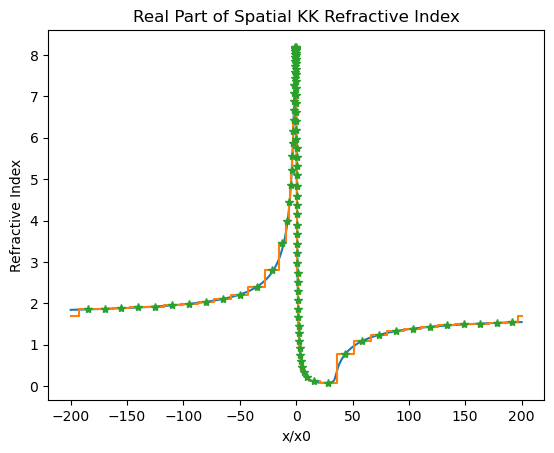

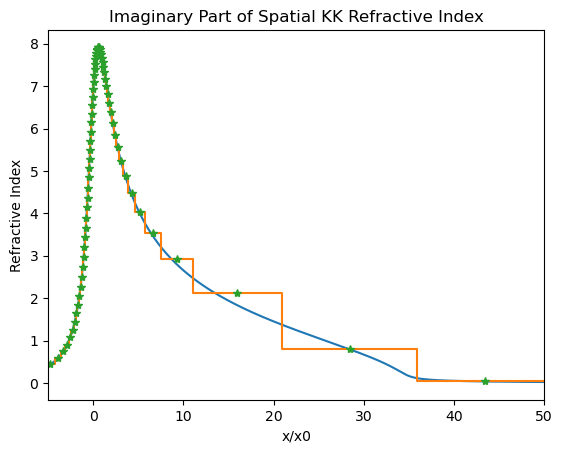

94


In [89]:
n_list, d_list = generate_n_and_d(0.01, 100, 1.7)
print(len(n_list))

In [16]:
# wavelength dependence calculation of RTA using incoherent TMM function (inc_tmm)

def TRA_func(n_list, d_list, c_list):
    pol = 'p'
    lambda_list = np.linspace(2,5,100)
    angle = 0
    T_list = np.zeros_like(lambda_list)
    R_list = np.zeros_like(lambda_list)
    A_list = np.zeros_like(lambda_list)
    
    for j, lamb in enumerate(lambda_list):
        T_list[j] = tmm.inc_tmm(pol, n_list, d_list, c_list, angle, lamb)['T']
        R_list[j] = tmm.inc_tmm(pol, n_list, d_list, c_list, angle, lamb)['R']
      #  T_list[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T']
      #  R_list[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R']
        A_list[j] = 1 - T_list[j] - R_list[j]

    return (T_list, R_list, A_list)
    

In [62]:
nkdata_sapphire = np.genfromtxt('lam_um_T_K_Al2O3_no_ko_ne_ke.dat')
kdata_sapphire = nkdata_sapphire[50:351, 3]
k_bulk = np.average(kdata_sapphire)
print(k_bulk)
n_list, d_list, c_list, losses_total = generate_StackofStacks(0.01, 0.00178063, 1.7, 1, 0)

4.268238205980066e-06
t_KK is: 3.892450000000001
t_inc is: 0.0
t_total is: 3.892450000000001
k_bulk from np.sum is: 4.26824083287538e-06
total losses are: 1.6613914029925778e-05


In [68]:
# calculate TRA of stack of stacks

A = 0.00178063
gam = 0.01
nb = 1.7
num_stacks = 1
t_prop = 0
n_list, d_list, c_list, losses_total = generate_StackofStacks(gam, A, nb, num_stacks, t_prop)

n_list_reversed = n_list[::-1]
d_list_reversed = d_list[::-1]
c_list_reversed = c_list[::-1]

T_list_LR, R_list_LR, A_list_LR = TRA_func(n_list, d_list, c_list)
T_list_RL, R_list_RL, A_list_RL = TRA_func(n_list_reversed, d_list_reversed, c_list_reversed)
lambda_list = np.linspace(2,5,100)

trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
emiss_bulk = 1 - trans_bulk

t_KK is: 3.892450000000001
t_inc is: 0.0
t_total is: 3.892450000000001
k_bulk from np.sum is: 4.26824083287538e-06
total losses are: 1.6613914029925778e-05


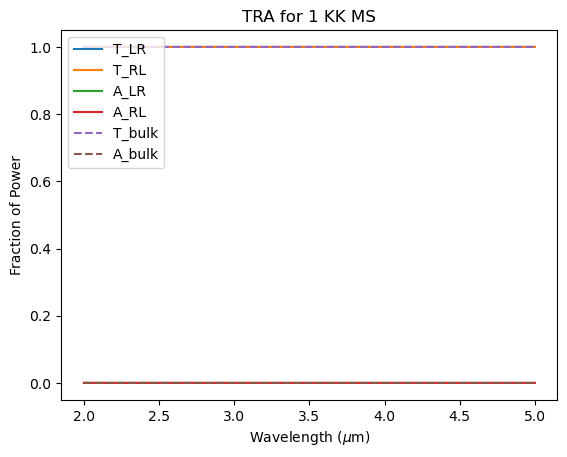

In [64]:
# plotting RTA forwards and backwards

plt.figure()
plt.plot(lambda_list,T_list_LR, label='T_LR')
#print(T_list_LR/trans_bulk)
plt.plot(lambda_list,T_list_RL, label='T_RL')
#plt.plot(lambda_list,R_list_LR, label='R_LR')
plt.plot(lambda_list,A_list_LR, label='A_LR')
#plt.plot(lambda_list,R_list_RL, label='R_RL')
plt.plot(lambda_list,A_list_RL, label='A_RL')
plt.plot(lambda_list,trans_bulk, '--', label='T_bulk')
plt.plot(lambda_list,emiss_bulk, '--', label='A_bulk')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Power')
plt.title(f'TRA for {num_stacks} KK MS');
plt.legend(loc='upper left')

In [69]:
# calculate FOM_KK and equivalently lossy bulk

delta_lamb = lambda_list[-1] - lambda_list[0]
FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
FOM_bulk = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

print(f'FOM_LR is: {FOM_LR}')
print(f'FOM_RL is: {FOM_RL}')
print(f'FOM_bulk is: {FOM_bulk}')

FOM_LR is: 15680.408047730496
FOM_RL is: 15681.371792052114
FOM_bulk is: 15680.430340113162


In [75]:
# sweep over number of layers N and calculate FOM for each stack

A = 0.1
gam = 0.01
nb = 1.7
t_prop = 0
FOM_LR = np.zeros(100)
FOM_RL = np.zeros(100)
FOM_bulk = np.zeros(100)
for i in range(1, 101):
    print(i)
    n_list, d_list, c_list, losses_total = generate_StackofStacks(gam, A, nb, i, t_prop)
    n_list_reversed = n_list[::-1]
    d_list_reversed = d_list[::-1]
    c_list_reversed = c_list[::-1]

    T_list_LR, R_list_LR, A_list_LR = TRA_func(n_list, d_list, c_list)
    T_list_RL, R_list_RL, A_list_RL = TRA_func(n_list_reversed, d_list_reversed, c_list_reversed)
    lambda_list = np.linspace(2,5,100)
    delta_lamb = lambda_list[-1] - lambda_list[0]
    trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
    emiss_bulk = 1 - trans_bulk

    FOM_LR[i-1] = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
    FOM_RL[i-1] = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
    FOM_bulk[i-1] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

1
t_KK is: 3.892450000000001
t_inc is: 0.0
t_total is: 3.892450000000001
k_bulk from np.sum is: 0.00023970446624177997
total losses are: 0.0009330376496228168
2
t_KK is: 3.892450000000001
t_inc is: 0.0
t_total is: 7.784900000000002
k_bulk from np.sum is: 0.00023970446624177997
total losses are: 0.0018660752992456335
3
t_KK is: 3.892450000000001
t_inc is: 0.0
t_total is: 11.677350000000004
k_bulk from np.sum is: 0.00023970446624177997
total losses are: 0.0027991129488684503
4
t_KK is: 3.892450000000001
t_inc is: 0.0
t_total is: 15.569800000000004
k_bulk from np.sum is: 0.00023970446624177997
total losses are: 0.003732150598491267
5
t_KK is: 3.892450000000001
t_inc is: 0.0
t_total is: 19.462250000000004
k_bulk from np.sum is: 0.00023970446624177997
total losses are: 0.004665188248114084
6
t_KK is: 3.892450000000001
t_inc is: 0.0
t_total is: 23.35470000000001
k_bulk from np.sum is: 0.00023970446624177997
total losses are: 0.0055982258977369005
7
t_KK is: 3.892450000000001
t_inc is: 0.0
t_

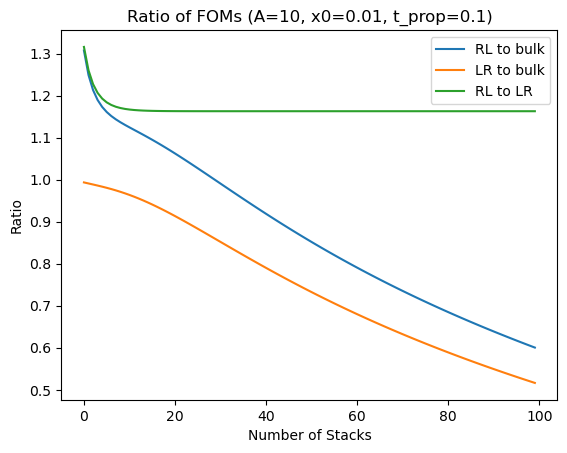

In [74]:
plt.plot(FOM_RL/FOM_bulk, label='RL to bulk')
plt.plot(FOM_LR/FOM_bulk, label='LR to bulk')
plt.plot(FOM_RL/FOM_LR, label='RL to LR')
plt.title('Ratio of FOMs (A=10, x0=0.01, t_prop=0.1)')
plt.xlabel('Number of Stacks')
plt.ylabel('Ratio')
plt.legend()

In [ ]:
arr = np.array([1, 3, 5, 7, 9])

midpoints = (arr[:-1] + arr[1:]) / 2

print(arr[:-1]) 